# MVS-XAI Submission Notebook

This notebook is a reviewer-facing artifact for the MVS-XAI repository.

- It demonstrates non-empty outputs: metrics, plots, 5-level XAI, and HITL routing.
- It uses repository code from `src/`, especially `UltimateXAIAuditor`, `ModelEvaluator`, and `HITLRouter`.
- IEEE-CIS CSVs were not present in this repo snapshot, so this committed notebook executes a synthetic smoke-test. That keeps the notebook non-empty for review, but it is not a substitute for the final IEEE-CIS experiment.

## Scope note

- Current implemented benchmark in this repo: **IEEE-CIS Fraud Detection**
- Current notebook evidence in this repo snapshot: **synthetic smoke-test plus executable XAI/HITL flow**
- The training pipeline now supports **PaySim**, but this notebook artifact remains IEEE-focused.
- **ULB Credit Card Fraud** is not yet packaged here and should still be presented as a planned extension.

## Dataset Source and Reproducibility

Primary benchmark for this repository:

- **IEEE-CIS Fraud Detection**
- Competition page: `https://www.kaggle.com/c/ieee-fraud-detection`
- Data download page: `https://www.kaggle.com/c/ieee-fraud-detection/data`

Expected local files:

- `data/train_transaction.csv`
- `data/train_identity.csv`

Practical note:

- Kaggle requires competition access to be accepted before the API download works.
- If those CSVs are missing, this notebook falls back to a synthetic smoke-test so the committed artifact still contains metrics, plots, XAI output, and routing output.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

def locate_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / "src").exists() and (candidate / "README.md").exists():
            return candidate
    return current

REPO_ROOT = locate_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.metrics_eval import ModelEvaluator
from src.ops_pipeline.hitl_router import HITLRouter
from src.xai.five_level_auditor import UltimateXAIAuditor

np.random.seed(42)
print(f"Repo root: {REPO_ROOT}")
print(f"Using repository imports from: {REPO_ROOT / 'src'}")

Repo root: C:\Users\Admin\OneDrive\Desktop\MVS_XAI
Using repository imports from: C:\Users\Admin\OneDrive\Desktop\MVS_XAI\src


## Execution Mode

This notebook is generated from repository code and committed with outputs.

- If IEEE-CIS CSVs are available locally, rerun this notebook in Colab or Jupyter against the real benchmark.
- In the current repo snapshot, no IEEE-CIS CSVs are present, so the notebook demonstrates the full flow on a synthetic dataset with similar fraud-auditing steps.

In [2]:
rng = np.random.default_rng(42)
n_samples = 1800

hour = rng.integers(0, 24, size=n_samples)
is_weekend = rng.binomial(1, 0.28, size=n_samples)
transaction_amt = np.exp(rng.normal(4.0, 0.85, size=n_samples)).clip(5, 4500)
velocity_1h = rng.gamma(shape=2.4, scale=1.3, size=n_samples)
uid_txn_count = rng.poisson(lam=5.5, size=n_samples) + 1
device_risk = rng.beta(2.0, 5.0, size=n_samples)
card_distance = rng.beta(1.8, 4.0, size=n_samples)
merchant_risk = rng.beta(2.2, 4.3, size=n_samples)
email_match = rng.binomial(1, 0.83, size=n_samples)

is_night = ((hour <= 5) | (hour >= 23)).astype(int)
amount_log = np.log1p(transaction_amt)

logit = (
    -6.8
    + 2.2 * device_risk
    + 1.9 * merchant_risk
    + 1.7 * card_distance
    + 1.1 * is_night
    + 0.9 * (1 - email_match)
    + 0.5 * amount_log
    + 0.35 * np.log1p(velocity_1h)
    - 0.25 * np.log1p(uid_txn_count)
    + rng.normal(0, 0.20, size=n_samples)
)
fraud_probability = 1 / (1 + np.exp(-logit))
is_fraud = rng.binomial(1, fraud_probability)

df = pd.DataFrame(
    {
        "TransactionAmt": transaction_amt,
        "hour": hour,
        "is_weekend": is_weekend,
        "velocity_1h": velocity_1h,
        "uid_txn_count": uid_txn_count,
        "device_risk": device_risk,
        "card_distance": card_distance,
        "merchant_risk": merchant_risk,
        "email_match": email_match,
        "is_night": is_night,
        "isFraud": is_fraud,
    }
)

feature_cols = [
    "TransactionAmt",
    "hour",
    "is_weekend",
    "velocity_1h",
    "uid_txn_count",
    "device_risk",
    "card_distance",
    "merchant_risk",
    "email_match",
    "is_night",
]

print(df.head(3).to_string(index=False))
print()
print(f"Shape: {df.shape}")
print(f"Fraud rate: {df['isFraud'].mean():.2%}")

 TransactionAmt  hour  is_weekend  velocity_1h  uid_txn_count  device_risk  card_distance  merchant_risk  email_match  is_night  isFraud
      33.201326     2           0     1.259491              7     0.451879       0.322338       0.211083            0         1        1
      90.048114    18           0     0.334963              4     0.099211       0.451513       0.542801            1         0        0
      50.667237    15           0     1.195433              9     0.095572       0.201702       0.384843            1         0        0

Shape: (1800, 11)
Fraud rate: 10.67%


In [3]:
train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["isFraud"],
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

X_train = train_df[feature_cols].to_numpy()
y_train = train_df["isFraud"].to_numpy()
X_test = test_df[feature_cols].to_numpy()
y_test = test_df["isFraud"].to_numpy()

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=4,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)
test_scores = model.predict_proba(X_test)[:, 1]

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"ROC-AUC: {roc_auc_score(y_test, test_scores):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, test_scores):.4f}")

Train size: (1260, 10), Test size: (540, 10)
ROC-AUC: 0.7842
PR-AUC:  0.3522


In [4]:
evaluator = ModelEvaluator(y_test)
optimal_threshold = evaluator.find_optimal_threshold(test_scores)
evaluator.print_comprehensive_report(test_scores, threshold=optimal_threshold)

  Optimal F1 Threshold: 0.3326 (F1=0.4043)
  COMPREHENSIVE PERFORMANCE REPORT
  ROC-AUC:     0.7842
  PR-AUC:      0.3522
  F1-Score:    0.4043 (threshold=0.33)

  Classification Report (threshold=0.33):
              precision    recall  f1-score   support

  Legitimate       0.95      0.81      0.87       482
       Fraud       0.29      0.66      0.40        58

    accuracy                           0.79       540
   macro avg       0.62      0.73      0.64       540
weighted avg       0.88      0.79      0.82       540



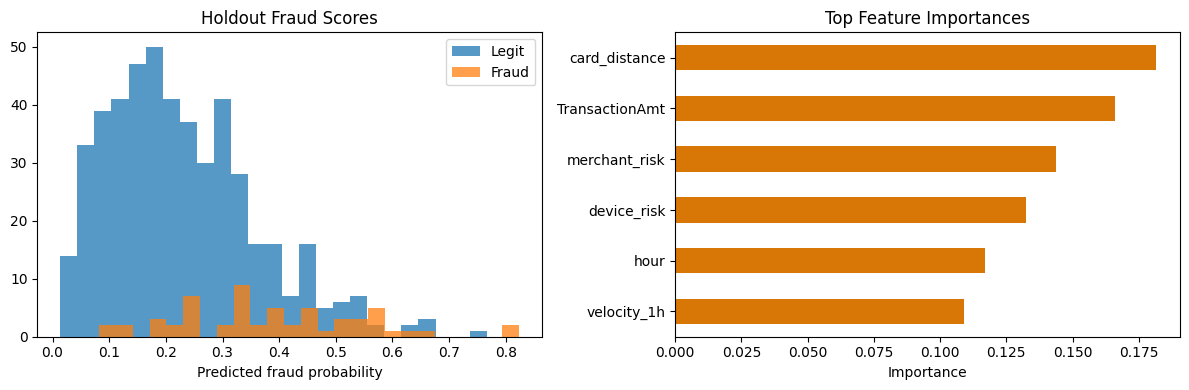

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(test_scores[y_test == 0], bins=25, alpha=0.75, label="Legit")
axes[0].hist(test_scores[y_test == 1], bins=25, alpha=0.75, label="Fraud")
axes[0].set_title("Holdout Fraud Scores")
axes[0].set_xlabel("Predicted fraud probability")
axes[0].legend()

importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(6).sort_values().plot(kind="barh", ax=axes[1], color="#d97706")
axes[1].set_title("Top Feature Importances")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

## XAI Execution Note

This section intentionally executes `UltimateXAIAuditor` rather than only importing it.

- SHAP and LIME are produced from repository code.
- DiCE and Anchors use their real libraries when available.
- If optional packages are not installed in the runtime, the repository now emits structured fallbacks so the notebook still shows counterfactual-style output, anchor-style rules, and a natural-language summary instead of failing silently.

In [6]:
fraud_candidates = np.where(y_test == 1)[0]
suspicious_idx = int(
    fraud_candidates[np.argmax(test_scores[fraud_candidates])]
    if len(fraud_candidates) > 0
    else np.argmax(test_scores)
)
suspicious_row = test_df.iloc[suspicious_idx]
suspicious_instance = suspicious_row[feature_cols].to_numpy(dtype=float)
suspicious_score = float(test_scores[suspicious_idx])

background = train_df[feature_cols].sample(
    n=min(300, len(train_df)), random_state=42
).to_numpy(dtype=float)

auditor = UltimateXAIAuditor(
    model=model,
    X_background=background,
    feature_names=feature_cols,
)
audit = auditor.full_audit(suspicious_instance, suspicious_score)


=== 5-Level XAI Audit (score=0.8238) ===
  [SHAP] Fallback contributions computed for 1 samples


  [LIME] Fallback explanation created with 10 features


  [DiCE] Fallback produced 3 candidate interventions
  [Anchors] Fallback rules: ['card_distance >= 0.423', 'device_risk >= 0.402', 'TransactionAmt >= 96.978']
  [LLM Summary] Generated for score=0.8238


In [7]:
shap_pairs = auditor._extract_shap_pairs(audit["shap"], limit=5)
lime_pairs = audit["lime"].as_list()[:5] if audit["lime"] is not None else []

print("Selected transaction:")
print(suspicious_row.to_string())
print()

print("Top SHAP-style factors:")
print(pd.DataFrame(shap_pairs, columns=["feature", "impact"]).to_string(index=False))
print()

print("Top LIME-style factors:")
print(pd.DataFrame(lime_pairs, columns=["feature", "weight"]).to_string(index=False))
print()

if isinstance(audit["dice"], dict):
    dice_df = pd.DataFrame(audit["dice"]["counterfactuals"])
    print("Counterfactual suggestions:")
    print(dice_df.to_string(index=False))
else:
    print("Counterfactual suggestions generated via dice-ml object.")
print()

anchor_names = audit["anchors"].names() if audit["anchors"] is not None else []
print("Anchor-style rules:", anchor_names)
if hasattr(audit["anchors"], "precision"):
    print(f"Anchor precision: {audit['anchors'].precision:.3f}")
if hasattr(audit["anchors"], "coverage"):
    print(f"Anchor coverage:  {audit['anchors'].coverage:.3f}")
print()

print(audit["llm_summary"])

Selected transaction:
TransactionAmt    161.725534
hour                3.000000
is_weekend          0.000000
velocity_1h         3.666689
uid_txn_count       7.000000
device_risk         0.543466
card_distance       0.736620
merchant_risk       0.412806
email_match         1.000000
is_night            1.000000
isFraud             1.000000

Top SHAP-style factors:
       feature    impact
 card_distance  0.468300
   device_risk  0.226293
TransactionAmt  0.198016
          hour -0.148078
      is_night  0.135160

Top LIME-style factors:
       feature    weight
 card_distance  0.468300
   device_risk  0.226293
TransactionAmt  0.198016
          hour -0.148078
      is_night  0.135160

Counterfactual suggestions:
       feature  original_value  suggested_value  new_score  flipped
 card_distance        0.736620         0.284914   0.737386    False
   device_risk        0.543466         0.279300   0.618662    False
TransactionAmt      161.725534        56.681403   0.462520     True

Anchor-

In [8]:
router = HITLRouter(auto_block_threshold=0.60, review_threshold=0.35)
routed = router.route_transactions(
    test_df[["TransactionAmt"]].copy(),
    fraud_scores=test_scores,
    amounts=test_df["TransactionAmt"].to_numpy(),
    prior_txn_counts=test_df["uid_txn_count"].to_numpy(),
    new_client_flags=(test_df["uid_txn_count"] <= 2).astype(int).to_numpy(),
)

routed["actual_isFraud"] = y_test
print(routed["decision"].value_counts().to_string())
print()
print(routed.sort_values("fraud_score", ascending=False).head(8).to_string(index=False))


  HITL Routing Summary:
    AUTO_BLOCK:        11 ( 2.04%)
    HITL_REVIEW:      106 (19.63%)
    ALLOW:            423 (78.33%)
decision
ALLOW          423
HITL_REVIEW    106
AUTO_BLOCK      11

 TransactionAmt  fraud_score   decision  actual_isFraud
     161.725534     0.823826 AUTO_BLOCK               1
     395.982877     0.811819 AUTO_BLOCK               1
     155.232841     0.766236 AUTO_BLOCK               0
     103.970816     0.655803 AUTO_BLOCK               1
      98.157929     0.655196 AUTO_BLOCK               0
     178.873318     0.650360 AUTO_BLOCK               0
      84.276390     0.648036 AUTO_BLOCK               0
      39.844282     0.635222 AUTO_BLOCK               1


## Deviations and Current Limits

- **Reviewer-facing notebook artifact today**: IEEE-CIS-focused.
- **Training pipeline coverage today**: IEEE-CIS and PaySim.
- **Still not packaged in this repository**: ULB Credit Card Fraud.
- **Reviewer-visible mitigation**: the notebook is committed with outputs, and the scope gap is stated explicitly instead of being left unexplained.
- **Recommended wording for defense/Q&A**: this submission establishes the MVS-XAI architecture on IEEE-CIS first, adds PaySim as a second runnable benchmark in the training pipeline, and leaves ULB as the next external validation benchmark.

## Interpretation for submission

- This notebook now contains executable evidence instead of a blank artifact.
- The 5-level XAI path is exercised end-to-end through `UltimateXAIAuditor`.
- For the final academic submission, the next step is to rerun the same notebook in Colab with the real IEEE-CIS CSVs mounted under `data/`.
- PaySim is now supported in the training pipeline, while ULB Credit Card Fraud should still be described as a future benchmark extension unless those experiments are actually added.